<a href="https://colab.research.google.com/github/LukeRDuob/AI-Labsheets/blob/main/L9_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Worksheet: Understanding Image Self-Supervised Contrastive Learning (DINO-style)

This worksheet helps you understand image self-supervised contrastive learning, using a simplified DINO-style student-teacher paradigm. It's designed to run in Google Colab (GPU recommended).

Learning objectives:
- Understand why multi-view augmentation is used in self-supervised learning.
- Implement a toy student/teacher (DINO-style) training loop with momentum teacher updates.
- Visualize learned representations and design simple experiments.

Run each cell sequentially in Colab. Cells are commented to explain the core ideas.

In [3]:
## 1) Preliminaries — install packages and detect GPU

# The following cell installs required packages in Colab.
# If torch is already installed in your environment you can skip/re-run selectively.
# Note: in Colab this cell may take a few minutes on first run.

!pip install -q torch torchvision timm scikit-learn matplotlib requests tqdm

# Python imports and device detection
import os
import torch
import torchvision
import torchvision.transforms as T
import timm
import matplotlib.pyplot as plt
import numpy as np
import requests
from PIL import Image
from tqdm import tqdm
import torch.nn as nn
import torch.nn.functional as F
from PIL import ImageOps
import random
from torchvision.transforms import Compose, RandomResizedCrop, RandomHorizontalFlip, ColorJitter, RandomGrayscale, GaussianBlur, ToTensor, Normalize
from torch.nn.utils import parameters_to_vector
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
import io

print('torch:', torch.__version__)
print('torchvision:', torchvision.__version__)
print('timm:', getattr(timm, '__version__', 'not installed'))

# Set device (GPU if available, otherwise CPU)
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

# make sure a small folder exists for images
os.makedirs('images', exist_ok=True)

torch: 2.9.0+cu128
torchvision: 0.24.0+cu128
timm: 1.0.24
Device: cuda:0


Saved images/img_1.jpg
Saved images/img_2.jpg
Saved images/img_3.jpg
Saved images/img_4.jpg
Saved images/img_5.jpg


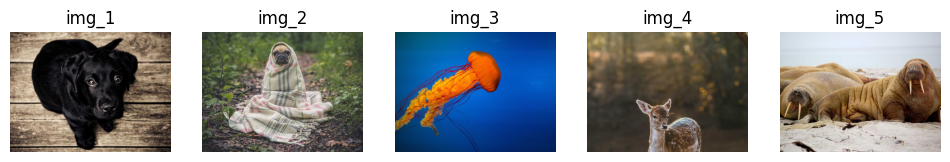

In [4]:
## 2) Download 5 example images from the web

# We'll download 5 fixed images (picsum) and save them to ./images for reproducibility.

urls = [
    'https://picsum.photos/id/237/800/600',
    'https://picsum.photos/id/1025/800/600',
    'https://picsum.photos/id/1069/800/600',
    'https://picsum.photos/id/1003/800/600',
    'https://picsum.photos/id/1084/800/600'
]

filenames = []
for i, url in enumerate(urls):
    r = requests.get(url)
    fname = f'images/img_{i+1}.jpg'
    with open(fname, 'wb') as f:
        f.write(r.content)
    filenames.append(fname)
    print('Saved', fname)

# Display thumbnails
plt.figure(figsize=(12,6))
for i, fname in enumerate(filenames):
    img = Image.open(fname).convert('RGB')
    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f'img_{i+1}')
plt.show()

In [15]:
from threading import local
from torchvision.transforms.transforms import RandomAdjustSharpness, RandomApply
## 3) Define Augmentations for DINO-style Multi-Crop

# DINO uses a multi-crop strategy: 2 high-resolution 'global' crops (e.g., 224x224)
# and multiple low-resolution 'local' crops (e.g., 96x96).
# All crops go through strong augmentation, but global crops use a larger scale range.

# Simple Solarize wrapper using PIL.ImageOps
class Solarize(object):
    """Applies Solarize augmentation to a PIL image."""
    def __init__(self, threshold=128):
        self.threshold = threshold

    def __call__(self, img):
        # TODO: Apply the ImageOps.solarize function using the threshold
        return ImageOps.solarize(img, self.threshold)

# Helper: builds a strong augmentation for global crops
def build_strong_transform(size):
    """Builds the strong augmentation pipeline for global crops."""
    # TODO: Create a T.Compose pipeline with:
    # 1. RandomResizedCrop (size=size, scale=(0.2, 1.0))
    # 2. RandomHorizontalFlip (p=0.5)
    # 3. RandomApply [T.ColorJitter(...)] (p=0.8)
    # 4. RandomGrayscale (p=0.2)
    # 5. RandomApply [T.GaussianBlur(...)] (p=0.5)
    # 6. RandomApply [Solarize(...)] (p=0.2)
    # 7. ToTensor()
    # 8. Normalize(...)

    transform = Compose([


        RandomResizedCrop(size=size, scale=(0.2, 1.0)),
        RandomHorizontalFlip(p=0.5),
        RandomApply([
            ColorJitter(brightness=0.4, contrast=0.4, saturation=0.2, hue=0.1)],
            p=0.8
        ),
        RandomGrayscale(p=0.2),
        RandomApply([
            GaussianBlur(kernel_size=23)],
            p=0.5

        ),
        RandomApply([
            Solarize()],
            p=0.2
        ),
        ToTensor(),
        Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      ]
    )
    return transform

# Helper: builds a (weaker) transform for local crops (smaller size)
def build_local_transform(size):
    """Builds the augmentation pipeline for local crops."""
    # TODO: Create a T.Compose pipeline with:
    # 1. RandomResizedCrop (size=size, scale=(0.05, 0.4)) <-- Note the different scale
    # 2. RandomHorizontalFlip (p=0.5)
    # 3. RandomApply [T.ColorJitter(...)] (p=0.5)
    # 4. RandomGrayscale (p=0.2)
    # 5. RandomApply [T.GaussianBlur(...)] (p=0.3)
    # 6. ToTensor()
    # 7. Normalize(...)
    local_transform = Compose([
            RandomResizedCrop(size=size, scale=(0.05, 0.4)),
            RandomHorizontalFlip(p=0.5),
            RandomApply(
                [ColorJitter(0.4,0.4,0.4,0.1)],
                p=0.5
            ),
            RandomGrayscale(p=0.2),
            RandomApply(
                [GaussianBlur(kernel_size=7)],
                p=0.3
            ),
            ToTensor(),
            Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
          ]
        )

    return local_transform

# Multi-crop generator: returns a tensor of shape (n_views, C, H, W)
def multi_crop_augment(pil_img, n_global=2, n_local=4, global_size=224, local_size=96):
    """Creates a list of augmented views (2 global, 4 local) and stacks them."""
    # TODO:
    # 1. Create an empty list `views`
    views = []
    # 2. Build the global transform `strong_g` using `build_strong_transform`
    strong_g = build_strong_transform(size=global_size)
    # 3. Build the local transform `local_t` using `build_local_transform`
    local_t = build_local_transform(size=local_size)

    # 4. Loop `n_global` times, applying `strong_g` to `pil_img` and appending to `views`
    for _ in range(n_global):
        views.append(strong_g(pil_img))

    # 5. Loop `n_local` times, applying `local_t` to `pil_img` and appending to `views`
    for _ in range(n_local):
        views.append(local_t(pil_img))

    # 6. Stack the list of views into a single tensor using `torch.stack`
    views = torch.stack(views, dim=0)
    return views

# Utility: unnormalize tensor -> numpy HWC in [0,1] for plotting
# This is a helper function, no implementation needed.
def tensor_to_image_np(tensor):
    """Converts a normalized tensor (C,H,W) back to a plottable numpy array (H,W,C)."""
    mean = np.array([0.485,0.456,0.406])[:, None, None]
    std = np.array([0.229,0.224,0.225])[:, None, None]
    arr = tensor.cpu().numpy()
    img = (arr * std + mean).clip(0,1)
    img = np.transpose(img, (1,2,0))
    return img

In [16]:
## 4) Multi-view dataset for DINO-style training

class MultiViewDataset(torch.utils.data.Dataset):
    """Returns multiple augmented views per image.
    Each item: (views_tensor, index) where views_tensor shape = (n_views, C, H, W)
    """
    def __init__(self, file_list, n_global=2, n_local=4, global_size=224, local_size=96):
        self.files = file_list
        # Store the augmentation parameters
        self.n_global = n_global
        self.n_local = n_local
        self.global_size = global_size
        self.local_size = local_size

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        path = self.files[idx]
        img = Image.open(path).convert('RGB')

        # TODO: STUDENT TASK
        # Use the `multi_crop_augment` function from the previous cell to generate views.
        # Pass in the img and the stored augmentation parameters.
        views = multi_crop_augment(img, n_global=2, n_local=4, global_size=96, local_size=96)
        return views, idx

# dataloader
# We use 2 global crops (224x224) and 4 local crops (96x96)
mv_ds = MultiViewDataset(filenames, n_global=2, n_local=4, global_size=224, local_size=96)
dl = torch.utils.data.DataLoader(mv_ds, batch_size=2, shuffle=True)

# quick iteration to show shapes
print("Running a quick test on the DataLoader...")
try:
    for batch_views, batch_idx in dl:
        # (B, n_views, C, H, W) -> n_views = n_global + n_local
        print('Batch shape (B, n_views, C, H, W):', batch_views.shape)
        break
    print("DataLoader test successful.")
except Exception as e:
    print(f"\nDataLoader test failed. Did you implement `multi_crop_augment` and `__getitem__`? Error: {e}")

Running a quick test on the DataLoader...
Batch shape (B, n_views, C, H, W): torch.Size([2, 6, 3, 96, 96])
DataLoader test successful.


In [17]:
## 5) Model: simple ResNet backbone + projection head
from torchvision.models import resnet18
class ProjectionHead(nn.Module):
    """A simple 2-layer MLP projection head, as used in DINO."""
    def __init__(self, in_dim=512, hidden_dim=512, out_dim=256):
        super().__init__()

        # TODO: STUDENT TASK:
        # Implement a two-layer MLP projection head.
        # It should be: Linear(in_dim, hidden_dim) -> GELU -> Linear(hidden_dim, out_dim)
        # Example:
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, out_dim)
        )

    def forward(self, x):
        # TODO: Pass x through the self.net
        return self.net(x)

class ResNetBackboneWithProj(nn.Module):
    """Wrapper module: ResNet18 backbone + ProjectionHead."""
    def __init__(self, out_dim=256):
        super().__init__()
        backbone = resnet18(weights=None) # Use pretrained=False or weights=None
        # remove the final fully-connected (classification) layer
        backbone.fc = nn.Identity()
        self.backbone = backbone
        # Add the projection head
        self.proj = ProjectionHead(in_dim=512, hidden_dim=512, out_dim=out_dim)

    def forward(self, x):
        # x shape: (B, C, H, W)
        # TODO: Pass x through the backbone, then the projection head
        feat = self.backbone(x)  # (B, 512)
        z = self.proj(feat)      # (B, out_dim)
        return z
        # pass # <-- TODO

# helper to create student and teacher models
def create_student_teacher(out_dim=256):
    student = ResNetBackboneWithProj(out_dim=out_dim).to(device)
    teacher = ResNetBackboneWithProj(out_dim=out_dim).to(device)
    # initialize teacher with student weights
    teacher.load_state_dict(student.state_dict())
    # Teacher parameters are not updated by gradients
    for p in teacher.parameters():
        p.requires_grad = False
    return student, teacher

# Create the models
try:
    student, teacher = create_student_teacher()
    print('Created student & teacher, param counts:',
          sum(p.numel() for p in student.parameters()),
          sum(p.numel() for p in teacher.parameters()))
except Exception as e:
    print(f"Error creating models. Did you implement ProjectionHead correctly? Error: {e}")

Created student & teacher, param counts: 11570496 11570496


In [18]:
## 6) Extract initial student representations (before training)

# Define a basic transform for inference (used for visualization)
# This is just a standard center-crop transform, not the multi-crop used in training.
basic_transform = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

# Collect and store representations from the freshly-initialized student model.
# This will be used for "before" visualization so we can compare pre/post training.
student.eval()
initial_feats = []
initial_paths = []
with torch.no_grad():
    for fname in filenames:
        img = Image.open(fname).convert('RGB')
        t = basic_transform(img).unsqueeze(0).to(device)  # (1,C,H,W)
        try:
            z = student(t)  # (1, D)
            initial_feats.append(z.cpu().numpy().squeeze())
            initial_paths.append(fname)
        except Exception as e:
            print(f"Error processing initial features. Did you implement ProjectionHead or ResNetBackboneWithProj? Error: {e}")
            break

if initial_feats:
    initial_feats = np.stack(initial_feats, axis=0)
    print('Initial features collected, shape =', initial_feats.shape)
else:
    print("Could not collect initial features. Skipping.")
# keep initial_feats in memory for later visualization

Initial features collected, shape = (5, 256)


In [19]:
from torch.autograd.grad_mode import no_grad
## 7) DINO-style loss (simplified) and teacher EMA update

class DINOLossSimplified(nn.Module):
    """Simplified DINO loss.
    Calculates cross-entropy between (centered/sharpened) teacher probs and student log-probs.
    Also manages the moving average center for the teacher outputs.
    """
    def __init__(self, out_dim=256, student_temp=0.1, teacher_temp=0.07, center_momentum=0.9):
        super().__init__()
        self.student_temp = student_temp
        self.teacher_temp = teacher_temp
        # running center for teacher outputs (for stability)
        self.center_momentum = center_momentum
        self.register_buffer("center", torch.zeros(1, out_dim).to(device))

    def forward(self, student_outputs, teacher_outputs):
        """
        student_outputs: (B*n_views, D) logits from student (no softmax yet)
        teacher_outputs: (B*n_views, D) teacher outputs (pre-softmax)
        We treat teacher softmax (with teacher_temp) as target distribution (stop grad).
        Then compute cross-entropy: - sum( teacher_probs * log_softmax(student_logits / student_temp) )
        """

        # TODO: STUDENT TASK: Implement the DINO loss calculation

        # 1) Detach teacher outputs (no gradients) and apply centering and sharpening (teacher_temp)
        t_out = teacher_outputs.detach()
        t_out_centered = (t_out - self.center) / self.teacher_temp
        teacher_probs = F.softmax(t_out_centered, dim=-1)  # soft targets

        # 2) Apply sharpening (student_temp) to student outputs and get log-probabilities
        s_logits = student_outputs / self.student_temp
        student_log_probs = F.log_softmax(s_logits, dim=-1)

        # 3) Calculate the cross-entropy loss
        loss = - (teacher_probs * student_log_probs).sum(dim=-1).mean()

        # 4) Update the center (moving average) using the detached teacher outputs
        batch_center = t_out.mean(dim=0, keepdim=True)
        self.center = self.center * self.center_momentum + batch_center * (1 - self.center_momentum)


        return loss



# EMA update for teacher
@torch.no_grad()
def update_teacher(student, teacher, momentum=0.996):
    """Applies the exponential moving average update to the teacher's parameters."""
    # TODO: STUDENT TASK:
    # For each parameter in student and teacher:
    for p_s, p_t in zip(student.parameters(), teacher.parameters()):
        p_t.data = p_t.data * momentum + p_s.data * (1.0 - momentum)


In [20]:
## 8) Short toy training loop (run a small number of steps on the 5 images)

# Move models to device and set up optimizer
student = student.to(device)
teacher = teacher.to(device)
optimizer = torch.optim.Adam(student.parameters(), lr=1e-4)
criterion = DINOLossSimplified(out_dim=256, student_temp=0.1, teacher_temp=0.07, center_momentum=0.9)

# training hyperparameters
total_steps = 60
momentum = 0.996 # DINO uses a momentum schedule, here we use a constant
print_every = 12

losses = []
param_diffs = []

# Ensure we start training
student.train()
# teacher.train() # Teacher is in eval mode conceptually, but train() mode for EMA updates
step = 0

print("Starting toy training loop...")

# TODO: STUDENT TASK: Implement the training loop
# The loop should run until `step >= total_steps`
# Inside the loop (iterate over the dataloader `dl`):
# 1. Get batch_views, (B, n_views, C, H, W)
# 2. Reshape `batch_views` to `(B*n_views, C, H, W)` and move to `device`
# 3. Forward pass the views through the `student`
# 4. Forward pass the views through the `teacher` (inside a `torch.no_grad()` block)
# 5. Calculate the `loss` using `criterion(student_outputs, teacher_outputs)`
# 6. Standard optimizer steps: zero_grad(), backward(), step()
# 7. Update the teacher using `update_teacher(student, teacher, momentum)`
# 8. Log loss and param_diff (code for this is provided below, you can use it)
# 9. Print progress every `print_every` steps
# 10. Increment `step` and break if `step >= total_steps`


# Example of how to structure the loop (fill in the TODOs):
while step < total_steps:
    for batch_views, batch_idx in dl:

        # TODO: 1. Get shape and 2. Reshape views
        B, n_views, C, H, W = batch_views.shape
        views = batch_views.view(-1, C, H, W).to(device)

        # TODO: 3. Forward student
        student_outputs = student(views)

        # TODO: 4. Forward teacher (no grad)
        with torch.no_grad():
            teacher_outputs = teacher(views)

        # TODO: 5. Calculate loss
        loss = criterion(student_outputs, teacher_outputs)

        # TODO: 6. Optimizer step
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # TODO: 7. Update teacher
        update_teacher(student, teacher, momentum)

        # 8. Logging (you can use this code)
        losses.append(loss.item())
        vec_s = parameters_to_vector([p for p in student.parameters() if p.requires_grad])
        vec_t = parameters_to_vector([p for p in teacher.parameters()])
        pdiff = torch.norm(vec_s - vec_t).item()
        param_diffs.append(pdiff)

        # 9. Print progress
        if step % print_every == 0 or step == 0:
            print(f"step {step}/{total_steps}, loss={loss.item():.4f}, param_diff={pdiff:.4f}")

        # 10. Increment step and break
        step += 1
        if step >= total_steps:
            break

print('Finished toy training')

# expose losses/param_diffs for plotting later
training_stats = {'losses': losses, 'param_diffs': param_diffs}

Starting toy training loop...
step 0/60, loss=3.2913, param_diff=0.3388
step 12/60, loss=5.1610, param_diff=1.2846
step 24/60, loss=5.2136, param_diff=1.6778
step 36/60, loss=5.1690, param_diff=1.9279
step 48/60, loss=5.1514, param_diff=2.0399
Finished toy training


Final features collected, shape = (5, 256)

Running visualizations...


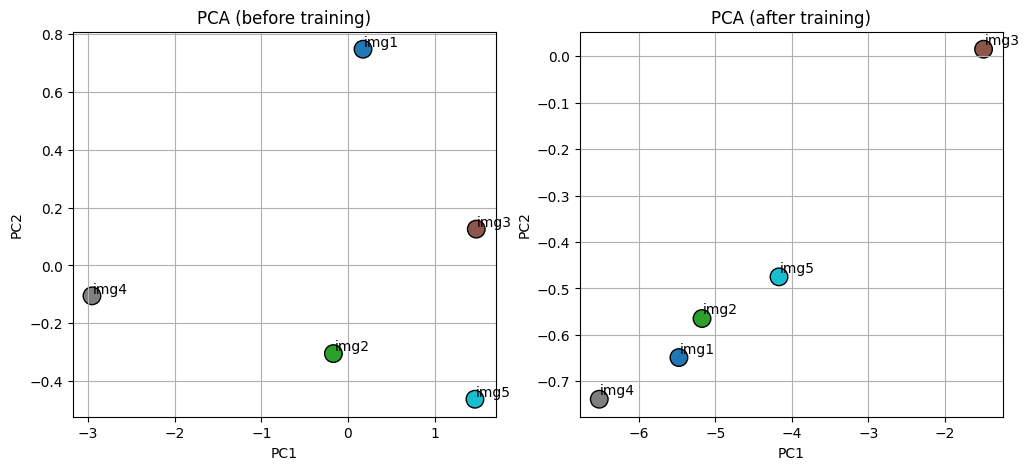

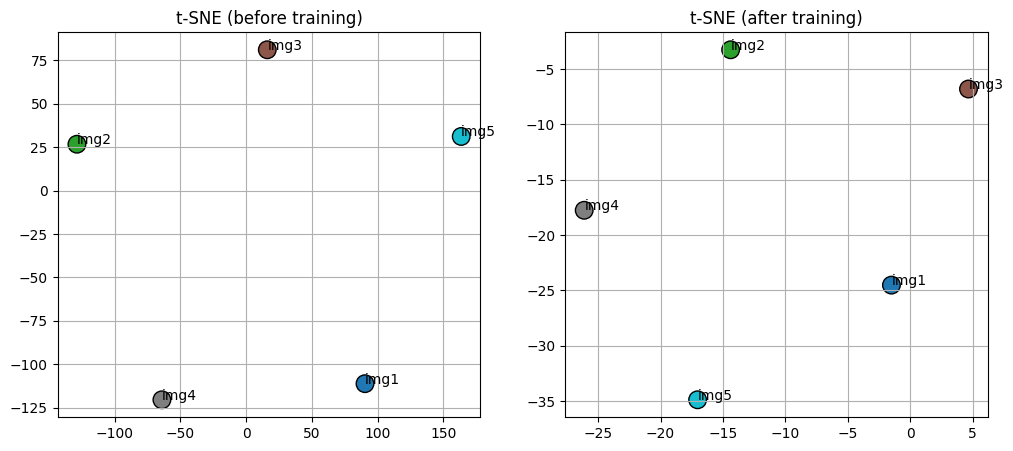

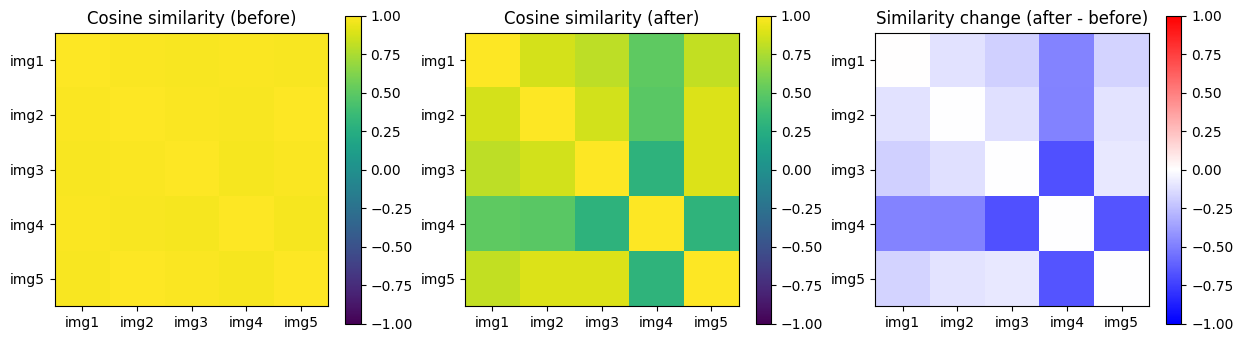

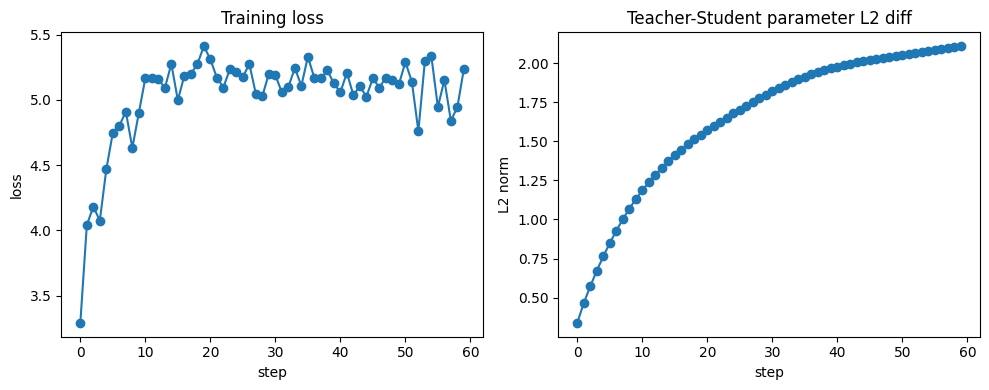

In [21]:
## 9) Visualize learned representations (PCA / t-SNE) — before vs after training

# This cell extracts the *final* features after training.
# It relies on `student` model being trained in the cell above.

student.eval()
final_feats = []
final_paths = []
with torch.no_grad():
    for fname in filenames:
        img = Image.open(fname).convert('RGB')
        t = basic_transform(img).unsqueeze(0).to(device)
        z = student(t)
        final_feats.append(z.cpu().numpy().squeeze())
        final_paths.append(fname)
final_feats = np.stack(final_feats, axis=0)
print('Final features collected, shape =', final_feats.shape)


# --- Visualization Code ---
# This code requires `initial_feats` (from cell 6) and `final_feats` (from this cell)

if 'initial_feats' not in globals() or not isinstance(initial_feats, np.ndarray):
    print('\nCannot run visualization: `initial_feats` not found or not computed.')
    print('Please run Cell 6 to extract initial features.')
else:
    print('\nRunning visualizations...')
    # PCA side-by-side
    pca = PCA(n_components=2)
    init_p2 = pca.fit_transform(initial_feats)
    final_p2 = pca.transform(final_feats)  # use same PCA fit for fair comparison

    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.scatter(init_p2[:,0], init_p2[:,1], s=160, c=range(len(initial_paths)), cmap='tab10', edgecolors='k')
    for i,p in enumerate(initial_paths):
        plt.text(init_p2[i,0]+0.01, init_p2[i,1]+0.01, f'img{i+1}', fontsize=10)
    plt.title('PCA (before training)')
    plt.xlabel('PC1'); plt.ylabel('PC2'); plt.grid(True)

    plt.subplot(1,2,2)
    plt.scatter(final_p2[:,0], final_p2[:,1], s=160, c=range(len(final_paths)), cmap='tab10', edgecolors='k')
    for i,p in enumerate(final_paths):
        plt.text(final_p2[i,0]+0.01, final_p2[i,1]+0.01, f'img{i+1}', fontsize=10)
    plt.title('PCA (after training)')
    plt.xlabel('PC1'); plt.ylabel('PC2'); plt.grid(True)
    plt.show()

    # t-SNE side-by-side (fit separately but keep same random seed)
    # Note: perplexity must be less than n_samples
    perplexity_val = max(2, min(30, len(initial_paths)-1))
    tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity_val)
    init_t2 = tsne.fit_transform(initial_feats)
    final_t2 = TSNE(n_components=2, random_state=42, perplexity=perplexity_val).fit_transform(final_feats)

    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.scatter(init_t2[:,0], init_t2[:,1], s=160, c=range(len(initial_paths)), cmap='tab10', edgecolors='k')
    for i,p in enumerate(initial_paths):
        plt.text(init_t2[i,0]+0.01, init_t2[i,1]+0.01, f'img{i+1}', fontsize=10)
    plt.title('t-SNE (before training)')
    plt.grid(True)

    plt.subplot(1,2,2)
    plt.scatter(final_t2[:,0], final_t2[:,1], s=160, c=range(len(final_paths)), cmap='tab10', edgecolors='k')
    for i,p in enumerate(final_paths):
        plt.text(final_t2[i,0]+0.01, final_t2[i,1]+0.01, f'img{i+1}', fontsize=10)
    plt.title('t-SNE (after training)')
    plt.grid(True)
    plt.show()

    # Cosine similarity matrices and difference (after - before)
    sim_init = cosine_similarity(initial_feats)
    sim_final = cosine_similarity(final_feats)
    sim_diff = sim_final - sim_init

    plt.figure(figsize=(15,4))
    plt.subplot(1,3,1)
    plt.imshow(sim_init, vmin=-1, vmax=1, cmap='viridis')
    plt.colorbar()
    plt.title('Cosine similarity (before)')
    plt.xticks(range(len(initial_paths)), [f'img{i+1}' for i in range(len(initial_paths))])
    plt.yticks(range(len(initial_paths)), [f'img{i+1}' for i in range(len(initial_paths))])

    plt.subplot(1,3,2)
    plt.imshow(sim_final, vmin=-1, vmax=1, cmap='viridis')
    plt.colorbar()
    plt.title('Cosine similarity (after)')
    plt.xticks(range(len(final_paths)), [f'img{i+1}' for i in range(len(final_paths))])
    plt.yticks(range(len(final_paths)), [f'img{i+1}' for i in range(len(final_paths))])

    plt.subplot(1,3,3)
    plt.imshow(sim_diff, cmap='bwr', vmin=-1, vmax=1)
    plt.colorbar()
    plt.title('Similarity change (after - before)')
    plt.xticks(range(len(final_paths)), [f'img{i+1}' for i in range(len(final_paths))])
    plt.yticks(range(len(final_paths)), [f'img{i+1}' for i in range(len(final_paths))])
    plt.show()

# Training curves (if available)
if 'training_stats' in globals():
    losses = training_stats.get('losses', [])
    pds = training_stats.get('param_diffs', [])

    if losses and pds:
        plt.figure(figsize=(10,4))
        plt.subplot(1,2,1)
        plt.plot(losses, marker='o')
        plt.title('Training loss')
        plt.xlabel('step')
        plt.ylabel('loss')

        plt.subplot(1,2,2)
        plt.plot(pds, marker='o')
        plt.title('Teacher-Student parameter L2 diff')
        plt.xlabel('step')
        plt.ylabel('L2 norm')
        plt.tight_layout()
        plt.show()
    else:
        print("Training stats are empty. Did the training loop (Cell 8) run correctly?")
else:
    print("training_stats not found. Did the training loop (Cell 8) run correctly?")

## 10) How to run this in Colab (short guide)

1. Upload this notebook to Google Colab or open via `File -> Upload notebook`.
2. Run the first cells to install packages and download images. If you are on Colab, enable GPU via `Runtime -> Change runtime type -> GPU` for faster runs.
3. Execute cells sequentially. Fill in the `TODO` sections in each implementation cell (Augmentations, Dataset, ProjectionHead, Loss, Training Loop).
4. After implementing all `TODO`s, run the whole notebook from the top. The visualization cell (9) should now show a difference between 'before' and 'after' features.

Notes:
- The code implements a simplified DINO-style approach for teaching. The real DINO has additional elements (e.g., more careful temperature scheduling, larger-scale training, and a specific projection head for centering).
- This worksheet is intentionally small-scale so it runs fast in Colab for demonstration and learning.

Enjoy experimenting!

## 11) Running Segment Anything (SAM) - vit_b

The following cells will guide you through running the smallest SAM model (`vit_b`) on one of the images we downloaded.


In [22]:
## 12) Install SAM and OpenCV

# We need the 'segment_anything' library from Meta and 'opencv' for image handling.
!pip install -q segment_anything opencv-python-headless

In [23]:
## 13) Download the SAM Model Checkpoint (vit_b)

# We will download the smallest model, "vit_b" (approx. 375MB)
# and save it to a new 'models' directory.
import os
os.makedirs('models', exist_ok=True)

# Check if the file already exists to avoid re-downloading
checkpoint_path = "models/sam_vit_b_01ec64.pth"
if not os.path.exists(checkpoint_path):
    print("Downloading SAM model checkpoint (vit_b)...")
    !wget -P models https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth
    print("Download complete.")
else:
    print("SAM model checkpoint already exists.")

--2026-02-18 12:16:54--  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 13.33.67.42, 13.33.67.73, 13.33.67.91, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|13.33.67.42|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 375042383 (358M) [binary/octet-stream]
Saving to: ‘models/sam_vit_b_01ec64.pth’

sam_vit_b_01ec64.pt 100%[===================>] 357.67M   127MB/s    in 2.8s    

2026-02-18 12:16:57 (127 MB/s) - ‘models/sam_vit_b_01ec64.pth’ saved [375042383/375042383]

Download complete.


In [24]:
## 14) Import SAM classes and Visualization Helpers

import cv2
from segment_anything import sam_model_registry, SamPredictor

# --- Visualization Helper Functions (from SAM notebook) ---
# No TODOs here, these are provided for you to use.

def show_mask(mask, ax, random_color=False):
    """Helper function to show a mask on an image."""
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)

def show_points(coords, labels, ax, marker_size=375):
    """Helper function to show prompt points on an image."""
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)

In [25]:
## 15) Load the SAM Model (vit_b)
import torch

print("Loading SAM model...")
# Define the model type and checkpoint path
model_type = "vit_b"
checkpoint_path = "models/sam_vit_b_01ec64.pth"

# Create the SAM model instance and move it to the device
sam = sam_model_registry[model_type](checkpoint=checkpoint_path)
sam.to('cuda' if torch.cuda.is_available() else 'cpu')

# Create the SamPredictor object
predictor = SamPredictor(sam)
print("Model loaded.")

Loading SAM model...
Model loaded.


In [26]:
## 16) Load and Prepare the Image

# We will use 'img_1.jpg' (the dog)
image_path = 'images/img_1.jpg'

# Load the image using OpenCV
image = cv2.imread(image_path)
# Convert from BGR (OpenCV default) to RGB (matplotlib/SAM default)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

print(f"Image shape: {image_rgb.shape}") # (Height, Width, Channels)

# Set the image for the predictor. This pre-processes the image.
print("Setting image for the predictor...")
predictor.set_image(image_rgb)
print("Image set.")

Image shape: (600, 800, 3)
Setting image for the predictor...
Image set.


In [27]:
## 17) Define a Prompt and Run Prediction
import numpy as np

# Let's pick a point on the dog's back as a prompt.
# Image is 800 (width) x 600 (height). A point around (500, 375) is on the dog.
# SAM expects points in (x, y) format.

# TODO: Try changing this point to segment different objects!
# (e.g., [400, 400] for the dog's leg, or [150, 150] for the background)
input_point = np.array([[500, 375]])
input_label = np.array([1]) # 1 means foreground, 0 means background

print(f"Predicting with point: {input_point}")

# Run the prediction
# This returns 3 masks by default, as the model isn't sure which level
# of detail you want (e.g., the whole dog, just the torso, just the harness).
masks, scores, logits = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    multimask_output=True, # Set to True to get 3 masks
)

print(f"Masks generated, shape: {masks.shape}") # (num_masks, height, width)
print(f"Scores: {scores}") # Confidence scores for each mask

Predicting with point: [[500 375]]
Masks generated, shape: (3, 600, 800)
Scores: [0.9492507  0.92560107 0.7886857 ]


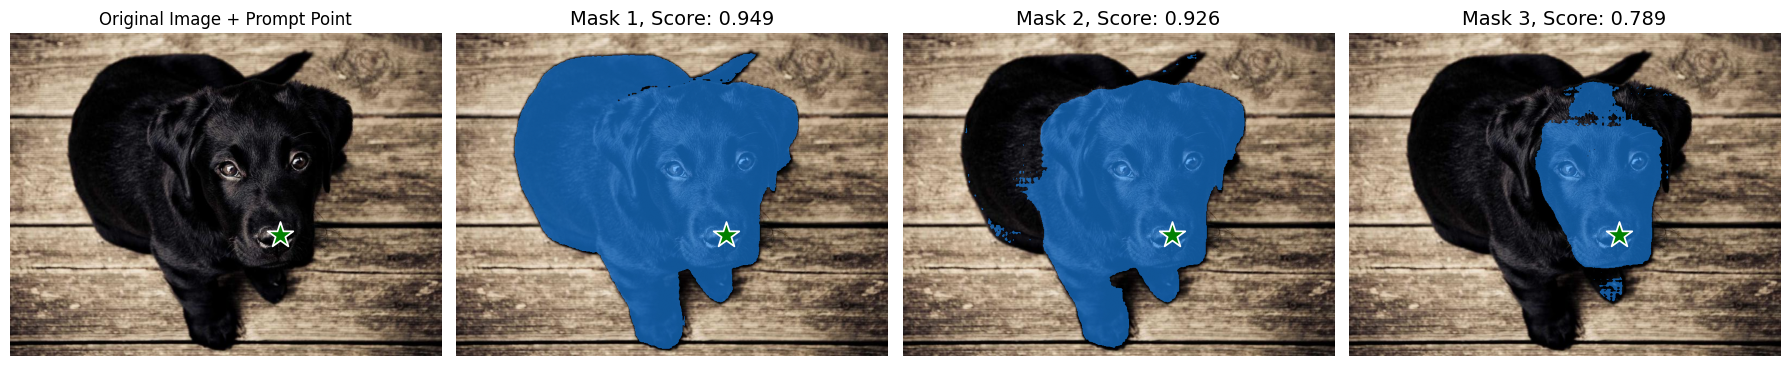

In [28]:
## 18) Visualize the Results

# We will display the original image and overlay the 3 masks
# with their confidence scores.
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 6))

# Show the original image
plt.subplot(1, 4, 1)
plt.imshow(image_rgb)
plt.title("Original Image + Prompt Point")
show_points(input_point, input_label, plt.gca())
plt.axis('off')

# Show the 3 predicted masks
for i, (mask, score) in enumerate(zip(masks, scores)):
    plt.subplot(1, 4, i + 2)
    plt.imshow(image_rgb)
    show_mask(mask, plt.gca())
    show_points(input_point, input_label, plt.gca())
    plt.title(f"Mask {i+1}, Score: {score:.3f}", fontsize=14)
    plt.axis('off')

plt.tight_layout()
plt.show()